## Setup

In [ ]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals

# Common imports
import numpy as np
import os
import pandas as pd


pd.set_option("display.max_rows", 999)

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12


# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

In [ ]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("California_Houses.csv")

df = pd.read_csv(DATA_PATH)

print(df.head())

The \<os> module to change your current (default) working directory to PATH, your new working directory

In [ ]:
import os
os.getcwd()
os.chdir(PATH)

**Importing the \<California_Houses.csv> dataset**

In [ ]:
df = pd.read_csv("California_Houses.csv")
print(df.head)

<bound method NDFrame.head of        Median_House_Value  Median_Income  Median_Age  Tot_Rooms  Tot_Bedrooms  \
0                452600.0         8.3252          41        880           129   
1                358500.0         8.3014          21       7099          1106   
2                352100.0         7.2574          52       1467           190   
3                341300.0         5.6431          52       1274           235   
4                342200.0         3.8462          52       1627           280   
...                   ...            ...         ...        ...           ...   
20635             78100.0         1.5603          25       1665           374   
20636             77100.0         2.5568          18        697           150   
20637             92300.0         1.7000          17       2254           485   
20638             84700.0         1.8672          18       1860           409   
20639             89400.0         2.3886          16       2785           616  

**Each row of the dataset represents one district in California**<br>
Have a look a the first and last few rows

In [ ]:
print(df.head())
print(df.tail())

   Median_House_Value  Median_Income  Median_Age  Tot_Rooms  Tot_Bedrooms  \
0            452600.0         8.3252          41        880           129   
1            358500.0         8.3014          21       7099          1106   
2            352100.0         7.2574          52       1467           190   
3            341300.0         5.6431          52       1274           235   
4            342200.0         3.8462          52       1627           280   

   Population  Households  Latitude  Longitude  Distance_to_coast  \
0         322         126     37.88    -122.23        9263.040773   
1        2401        1138     37.86    -122.22       10225.733072   
2         496         177     37.85    -122.24        8259.085109   
3         558         219     37.85    -122.25        7768.086571   
4         565         259     37.85    -122.25        7768.086571   

   Distance_to_LA  Distance_to_SanDiego  Distance_to_SanJose  \
0   556529.158342         735501.806984         67432.5170

### Creating a categorical  variable \<Closest_city> indicating the closest CA city and drop the distance to each city

In [ ]:
#Preparing the columns to explore
city_columns = {
    "Distance_to_LA": "Los Angeles",
    "Distance_to_SanDiego": "San Diego",
    "Distance_to_SanJose": "San Jose",
    "Distance_to_SanFrancisco": "San Francisco"
}

#Creating the new "Closest city" column
df["Closest_city"] = df[list(city_columns.keys())].idxmin(axis=1).map(city_columns)

df["Closest_city"] = df["Closest_city"].astype("category")

#Dropping the distance's columns
df = df.drop(columns=list(city_columns.keys()))

#Implementing it to the housing df
housing = df

In [ ]:
#Checking the new column
print(df.tail())
print(df.sample(10))
print(df["Closest_city"].value_counts())


       Median_House_Value  Median_Income  Median_Age  Tot_Rooms  Tot_Bedrooms  \
20635             78100.0         1.5603          25       1665           374   
20636             77100.0         2.5568          18        697           150   
20637             92300.0         1.7000          17       2254           485   
20638             84700.0         1.8672          18       1860           409   
20639             89400.0         2.3886          16       2785           616   

       Population  Households  Latitude  Longitude  Distance_to_coast  \
20635         845         330     39.48    -121.09      162031.481121   
20636         356         114     39.49    -121.21      160445.433537   
20637        1007         433     39.43    -121.22      153754.341182   
20638         741         349     39.43    -121.32      152005.022239   
20639        1387         530     39.37    -121.24      146866.196892   

        Closest_city  
20635  San Francisco  
20636  San Francisco  
20637

**Displaying the summary of your new dataframe**

In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Median_House_Value  20640 non-null  float64 
 1   Median_Income       20640 non-null  float64 
 2   Median_Age          20640 non-null  int64   
 3   Tot_Rooms           20640 non-null  int64   
 4   Tot_Bedrooms        20640 non-null  int64   
 5   Population          20640 non-null  int64   
 6   Households          20640 non-null  int64   
 7   Latitude            20640 non-null  float64 
 8   Longitude           20640 non-null  float64 
 9   Distance_to_coast   20640 non-null  float64 
 10  Closest_city        20640 non-null  category
dtypes: category(1), float64(5), int64(5)
memory usage: 1.6 MB


# Part 1 - Data explorations

### Finding out what categories exist in 'Closest_city' column and how many districts belong to each category.


In [ ]:
housing.groupby('Closest_city').size().reset_index(name='District_count')

/tmp/ipykernel_11158/2597075260.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  housing.groupby('Closest_city').size().reset_index(name='District_count')


,Closest_city,District_count
0,Los Angeles,9823
1,San Diego,1999
2,San Francisco,5054
3,San Jose,3764


### Showing a summary of the quantitative attributes


In [ ]:
cols_to_exclude = ['Latitude', 'Longitude']
columns_to_show = housing.drop(columns=cols_to_exclude)
columns_to_show.describe(include='number')

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Distance_to_coast
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,206855.816909,3.870671,28.639486,2635.763081,537.898014,1425.476744,499.539680,40509.264883
std,115395.615874,1.899822,12.585558,2181.615252,421.247906,1132.462122,382.329753,49140.039160
min,14999.000000,0.499900,1.000000,2.000000,1.000000,3.000000,1.000000,120.676447
25%,119600.000000,2.563400,18.000000,1447.750000,295.000000,787.000000,280.000000,9079.756762
50%,179700.000000,3.534800,29.000000,2127.000000,435.000000,1166.000000,409.000000,20522.019101
75%,264725.000000,4.743250,37.000000,3148.000000,647.000000,1725.000000,605.000000,49830.414479
max,500001.000000,15.000100,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,333804.686371


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

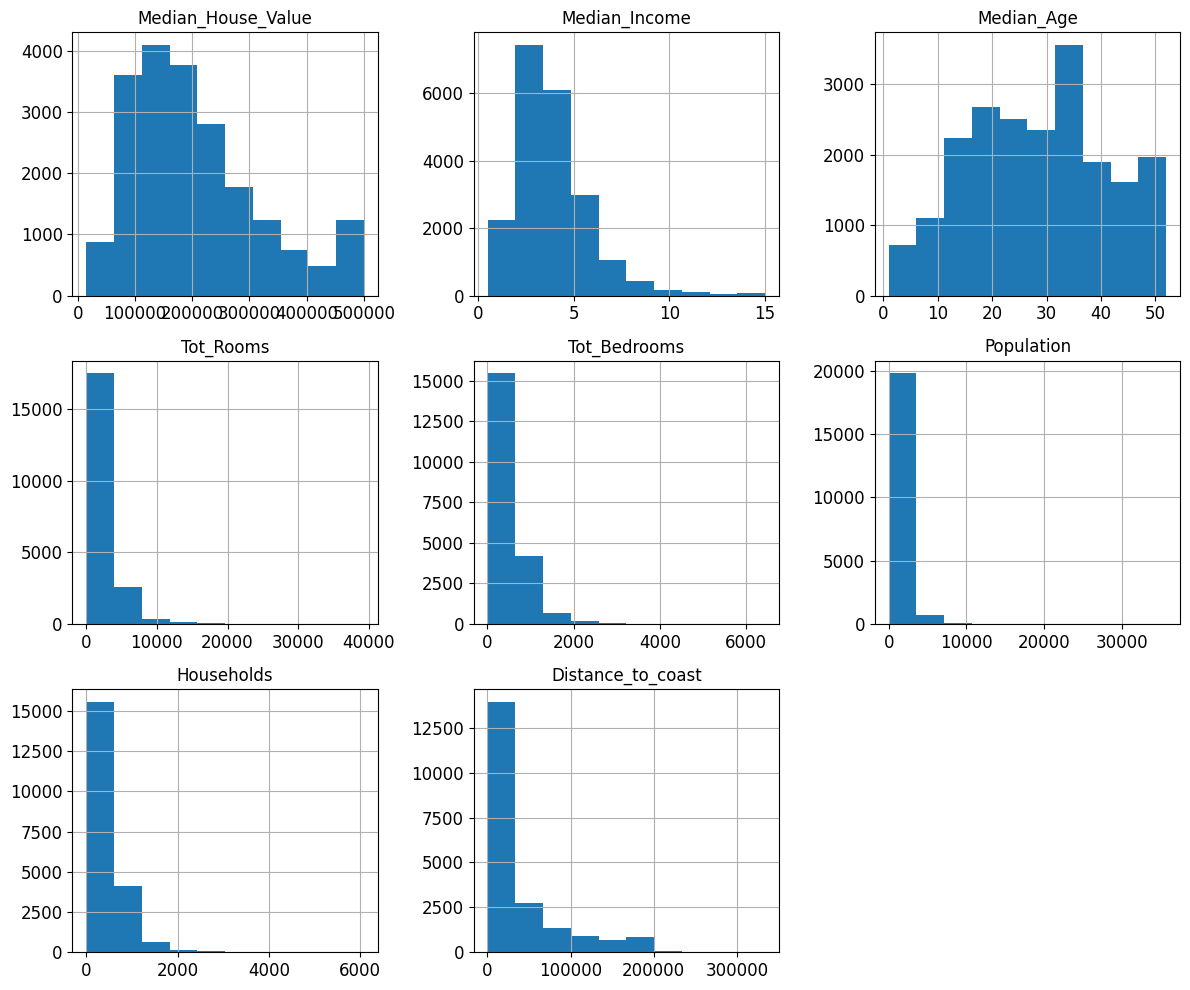

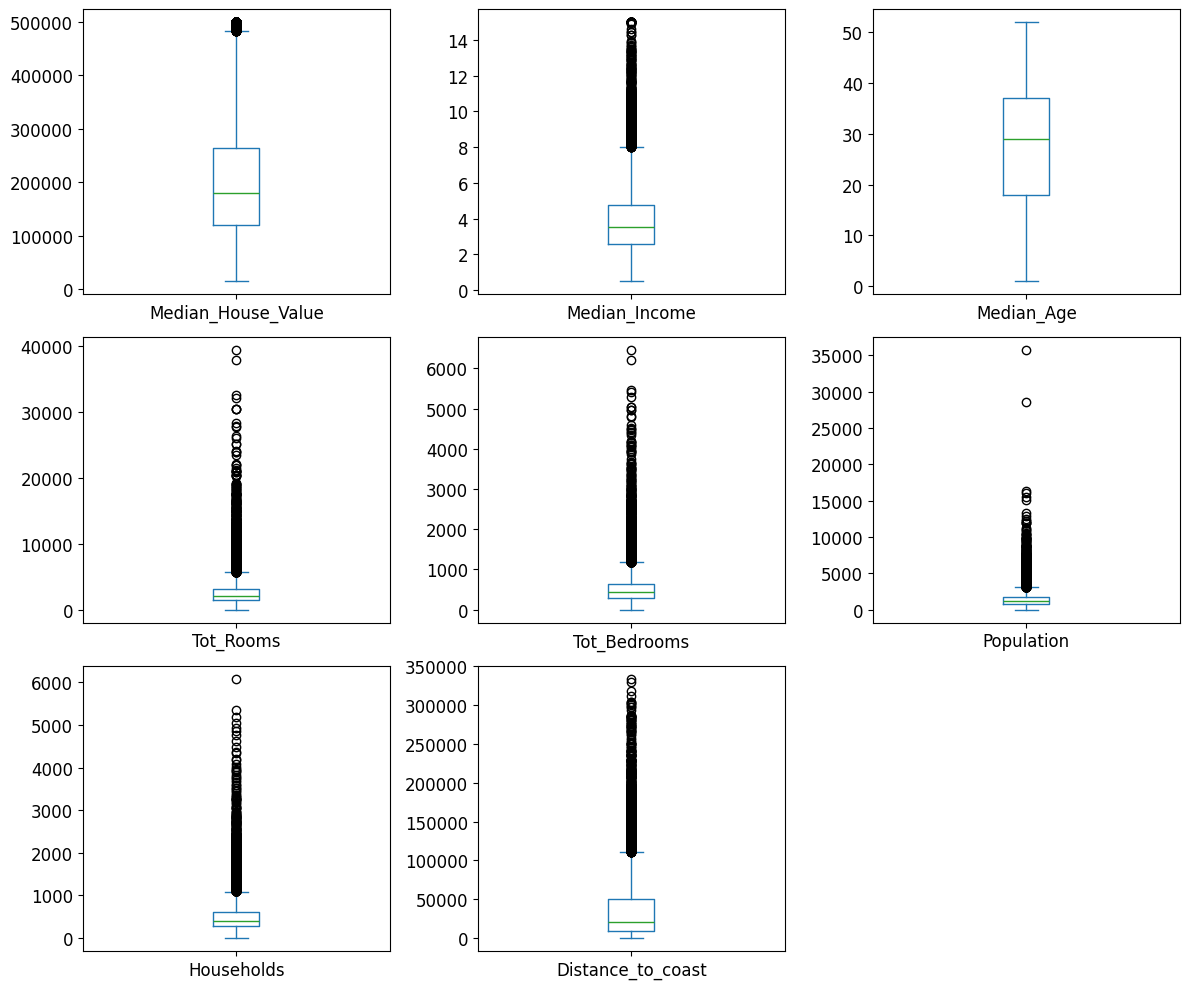

In [ ]:
columns_to_show.hist(figsize=(12, 10))
plt.tight_layout()
columns_to_show.plot(kind='box', subplots=True, layout=(3,3), figsize=(12,10))
plt.tight_layout()
plt.show()
plt.show()


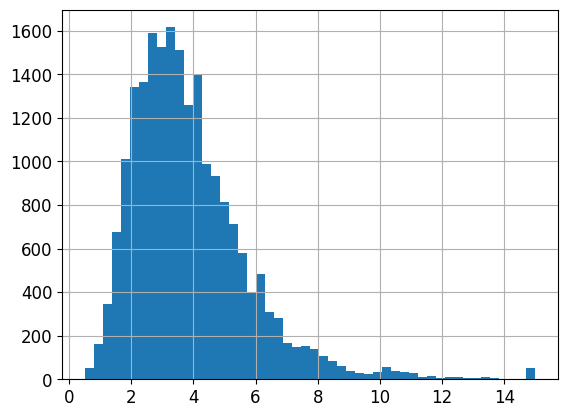

In [ ]:
housing["Median_Income"].hist(bins=50)
plt.show()

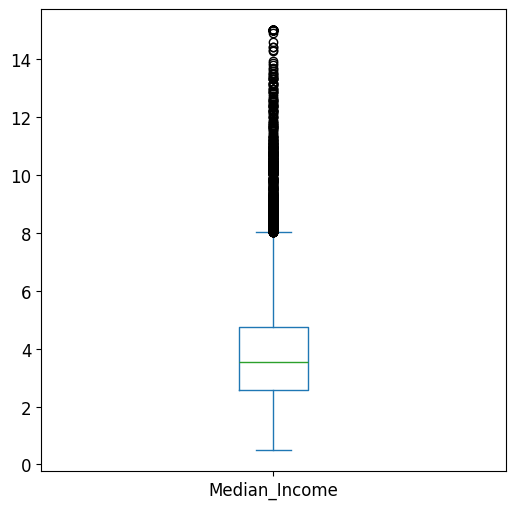

In [ ]:
housing["Median_Income"].plot(kind='box', figsize=(6,6))
plt.show()


In [ ]:
cat=[np.min(housing["Median_Income"])]
for i in [0.20, 0.40, 0.60, 0.80]:
    cat.append(housing["Median_Income"].quantile(i))
cat.append(np.max(housing["Median_Income"]))
print(cat)

[0.4999, np.float64(2.3523), np.float64(3.1406), np.float64(3.9669399999999997), np.float64(5.10972), 15.0001]


In [ ]:
housing["income_cat"]=pd.cut(housing["Median_Income"], bins=cat, labels = [1,2,3,4,5], include_lowest=True)

In [ ]:
housing["income_cat"].value_counts()

,count
income_cat,
2,4131
1,4130
4,4128
5,4128
3,4123


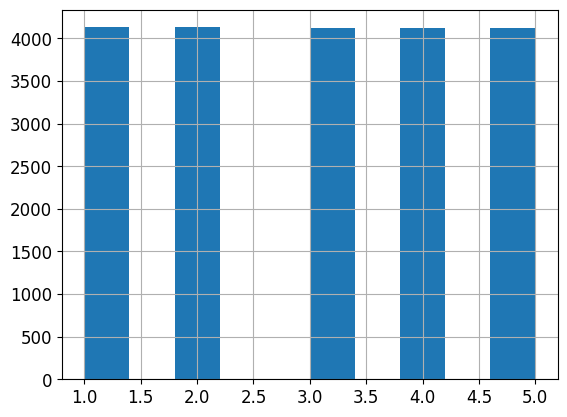

In [ ]:
housing["income_cat"].hist();

In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Median_House_Value  20640 non-null  float64 
 1   Median_Income       20640 non-null  float64 
 2   Median_Age          20640 non-null  int64   
 3   Tot_Rooms           20640 non-null  int64   
 4   Tot_Bedrooms        20640 non-null  int64   
 5   Population          20640 non-null  int64   
 6   Households          20640 non-null  int64   
 7   Latitude            20640 non-null  float64 
 8   Longitude           20640 non-null  float64 
 9   Distance_to_coast   20640 non-null  float64 
 10  Closest_city        20640 non-null  category
 11  income_cat          20640 non-null  category
dtypes: category(2), float64(5), int64(5)
memory usage: 1.6 MB


### Creating a Test Set through stratified random sampling on the income variable

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
#Creation of a stratified Test set
train_strat, test_strat = train_test_split(
    housing,
    test_size=0.2,
    random_state=42,
    stratify=housing['income_cat']
)

print(test_strat['income_cat'].value_counts(normalize=True))
print(train_strat['income_cat'].value_counts(normalize=True))

income_cat
1    0.200097
2    0.200097
4    0.200097
5    0.200097
3    0.199612
Name: proportion, dtype: float64
income_cat
2    0.200157
1    0.200097
4    0.199976
5    0.199976
3    0.199794
Name: proportion, dtype: float64


Now generating an equivalent random split without stratification

In [ ]:
#Creation of a non stratified Test set
train_random, test_random = train_test_split(
    housing,
    test_size=0.2,
    random_state=42
)

print(test_random['income_cat'].value_counts(normalize=True))
print(train_random['income_cat'].value_counts(normalize=True))

income_cat
3    0.205184
2    0.203973
1    0.202762
4    0.198886
5    0.189196
Name: proportion, dtype: float64
income_cat
5    0.202701
4    0.200279
1    0.199431
2    0.199188
3    0.198401
Name: proportion, dtype: float64


In [ ]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(housing),
    "Stratified": income_cat_proportions(test_strat),
    "Random": income_cat_proportions(test_random),
}).sort_index()

compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100

In [ ]:
compare_props

,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.200097,0.200097,0.202762,1.331719,-1.421085e-14
2,0.200145,0.200097,0.203973,1.912370,-2.420721e-02
3,0.199758,0.199612,0.205184,2.716469,-7.276255e-02
4,0.200000,0.200097,0.198886,-0.557171,4.844961e-02
5,0.200000,0.200097,0.189196,-5.402132,4.844961e-02


**For safety, copying the stratified train set to be used for modeling** <br>


In [ ]:
houses_df = train_strat.copy()

### Data Visualization : scatter plots

**Ploting each row (observation) in the dataset as a geographical point** <br>

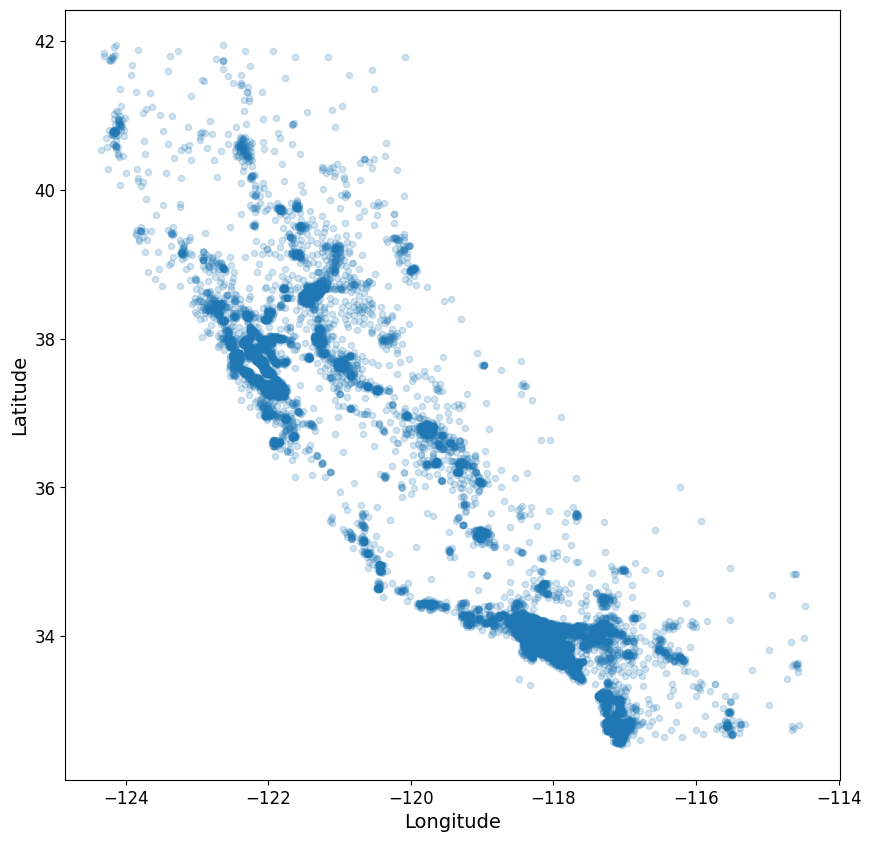

In [ ]:
import matplotlib.pyplot as plt

houses_df.plot(
    kind="scatter",
    x="Longitude",
    y="Latitude",
    figsize=(10,10),
    alpha=0.2
)

plt.show()

### Geographic map of California houses values per district with population density

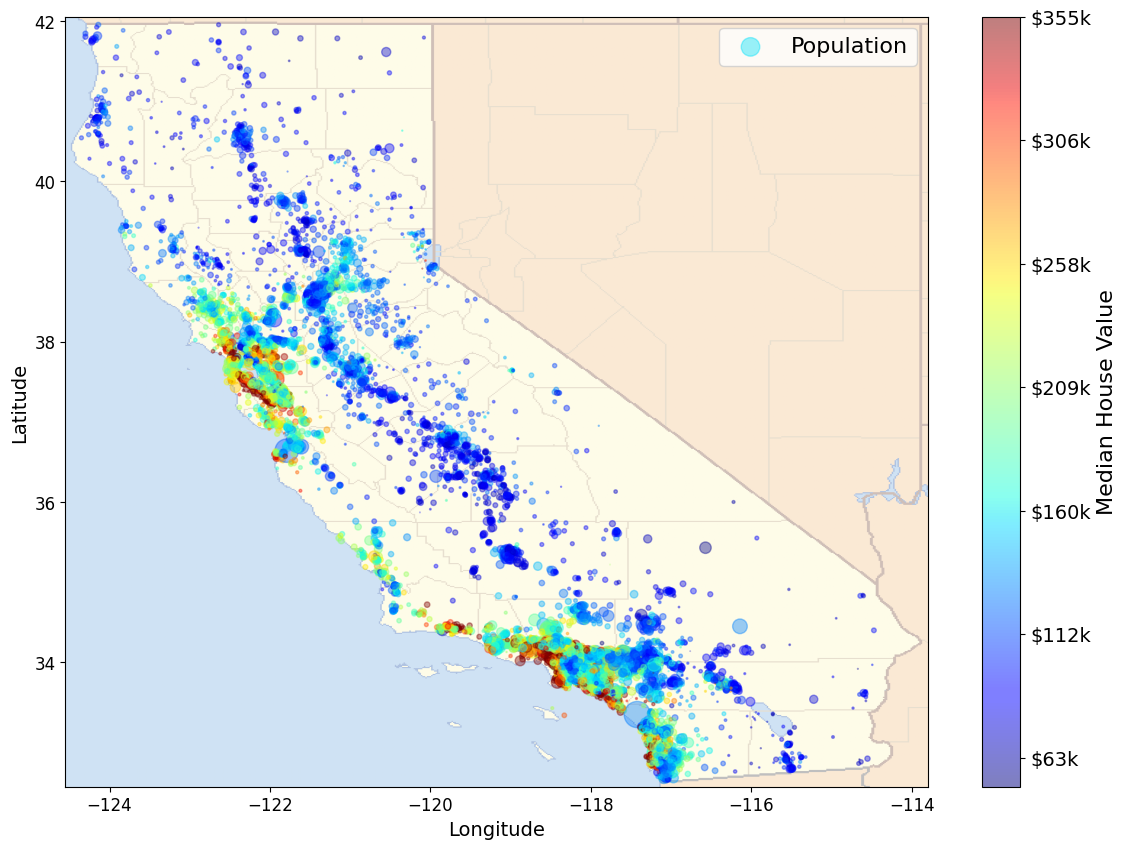

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.image as mpimg
california_img=mpimg.imread("california.png")
ax = houses_df.plot(kind="scatter", x="Longitude", y="Latitude", figsize=(14,10),
                       s=houses_df['Population']/100, label="Population",
                       c="Median_House_Value", cmap=plt.get_cmap("jet"),colorbar=False, alpha=0.4)
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5,cmap=plt.get_cmap("jet"))
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

prices = houses_df["Median_House_Value"]
tick_values = np.linspace(prices.min(), prices.max(), 11)
cbar = plt.colorbar()
cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in tick_values], fontsize=14)
cbar.set_label('Median House Value', fontsize=16)

plt.legend(fontsize=16)
plt.show()

### Bivariate Analysis

Computing the correlation matrix of all the quantitative variables <br>

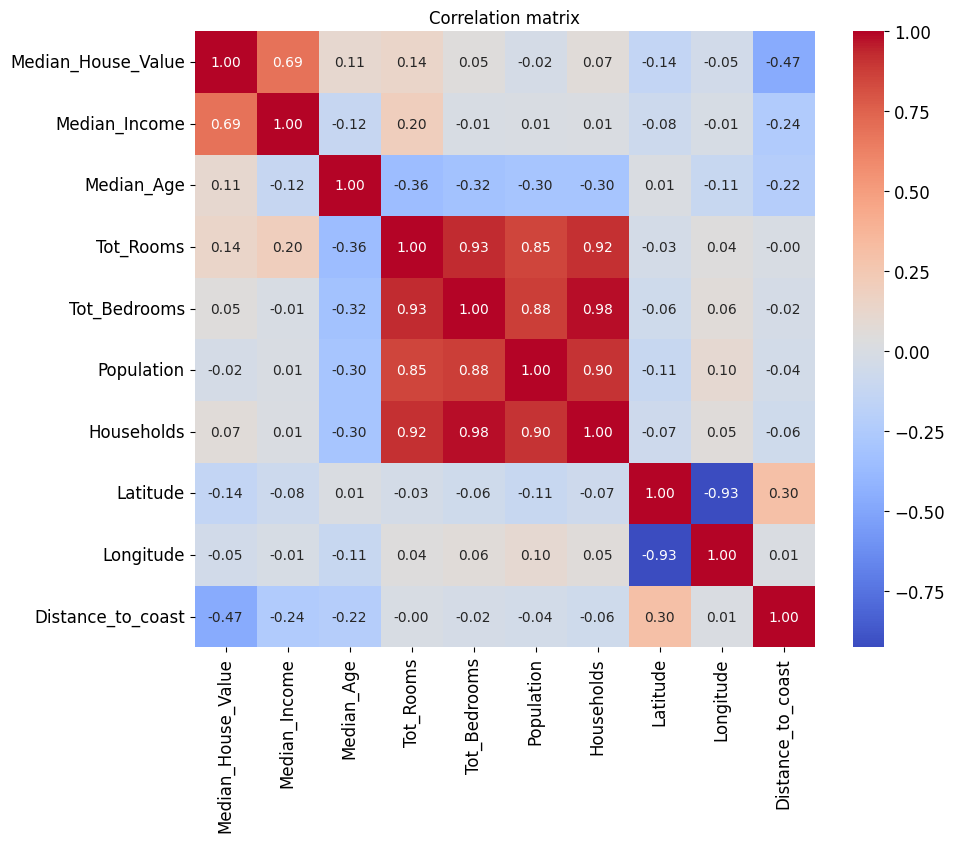

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

houses_cor = houses_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(houses_cor, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

Displaying the most important correlations with the target variable : \<Median_House_Value> <br>


In [ ]:
houses_cor["Median_House_Value"].sort_values(ascending=False)

,Median_House_Value
Median_House_Value,1.000000
Median_Income,0.689597
Tot_Rooms,0.136635
Median_Age,0.105611
Households,0.066550
Tot_Bedrooms,0.052198
Population,-0.023350
Longitude,-0.046849
Latitude,-0.141518
Distance_to_coast,-0.466959


**Providing the scatter plots of those predictors with the target**

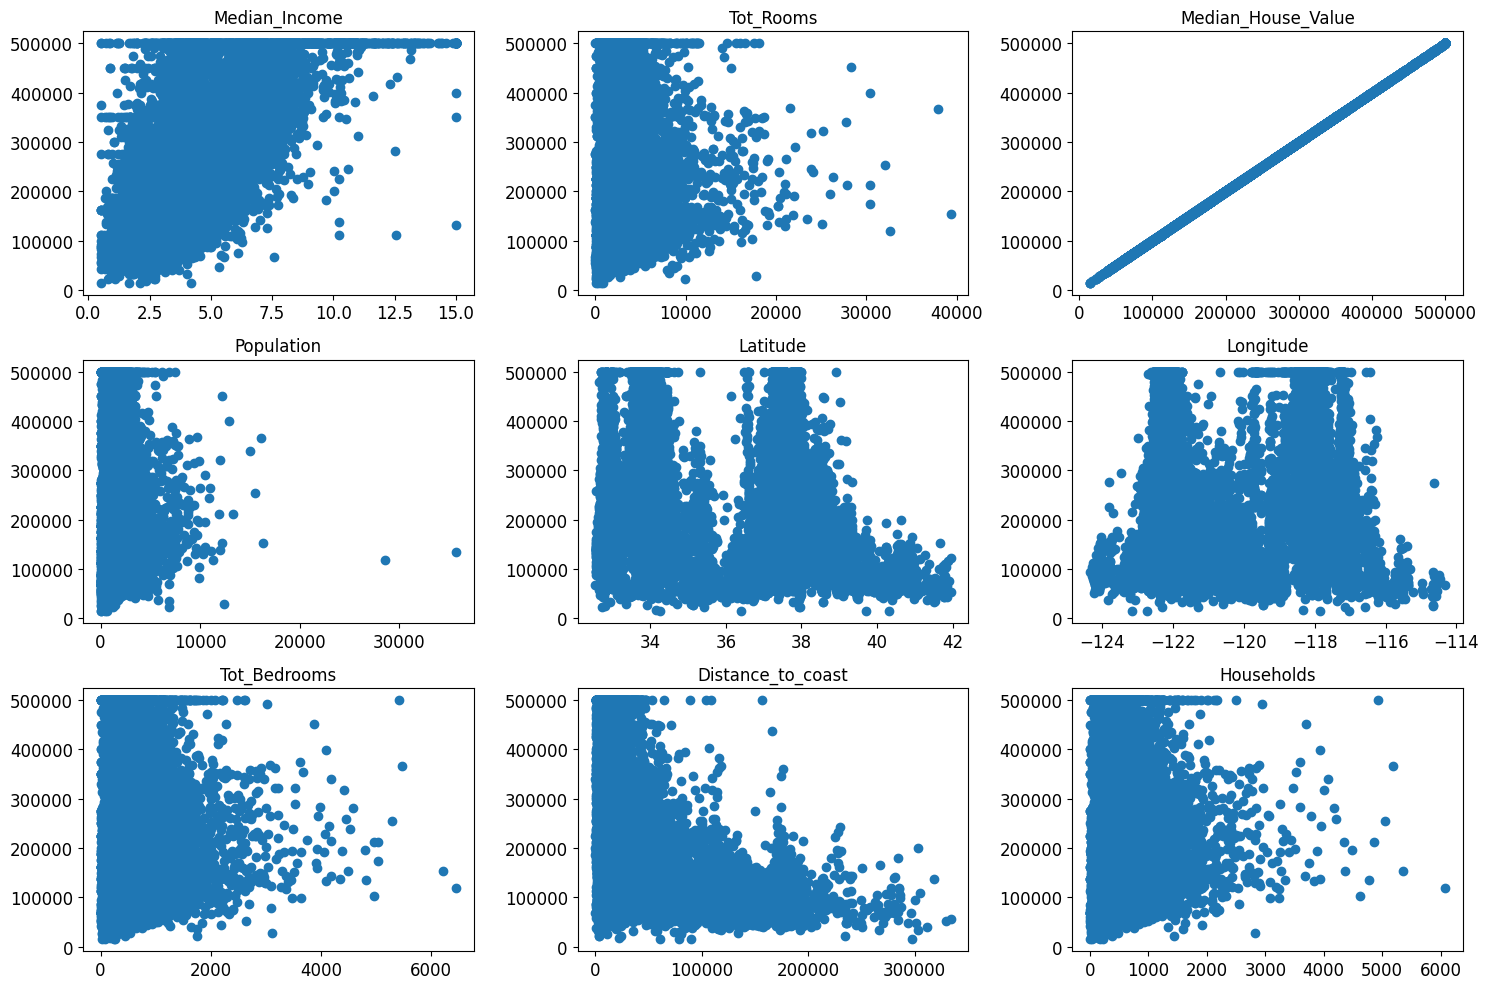

In [ ]:
#Scatter plots of predictors with the target
predictors = [
    'Median_Income',
    'Tot_Rooms',
    'Median_House_Value',
    'Population',
    'Latitude',
    'Longitude',
    'Tot_Bedrooms',
    'Distance_to_coast',
    'Households'
]

fig, axes = plt.subplots(3, 3, figsize=(15,10))  # 2 lines, 3 columns
axes = axes.flatten()

for i, col in enumerate(predictors):
    axes[i].scatter(df[col], df['Median_House_Value'])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

**Creating three new variables :**
1. Rooms per household
2. Bedrooms per rooms
3. People per household

In [ ]:
#####################################

df['Rooms_per_household'] = df['Tot_Rooms'] / df['Households']
df['Bedrooms_per_room'] = df['Tot_Bedrooms'] / df['Tot_Rooms']
df['People_per_household'] = df['Population'] / df['Households']
print(df.head())

#####################################

   Median_House_Value  Median_Income  Median_Age  Tot_Rooms  Tot_Bedrooms  \
0            452600.0         8.3252          41        880           129   
1            358500.0         8.3014          21       7099          1106   
2            352100.0         7.2574          52       1467           190   
3            341300.0         5.6431          52       1274           235   
4            342200.0         3.8462          52       1627           280   

   Population  Households  Latitude  Longitude  Distance_to_coast  \
0         322         126     37.88    -122.23        9263.040773   
1        2401        1138     37.86    -122.22       10225.733072   
2         496         177     37.85    -122.24        8259.085109   
3         558         219     37.85    -122.25        7768.086571   
4         565         259     37.85    -122.25        7768.086571   

    Closest_city income_cat  Rooms_per_household  Bedrooms_per_room  \
0  San Francisco          5             6.984127   

**Let us again look at the correlation between the predictors and the target**

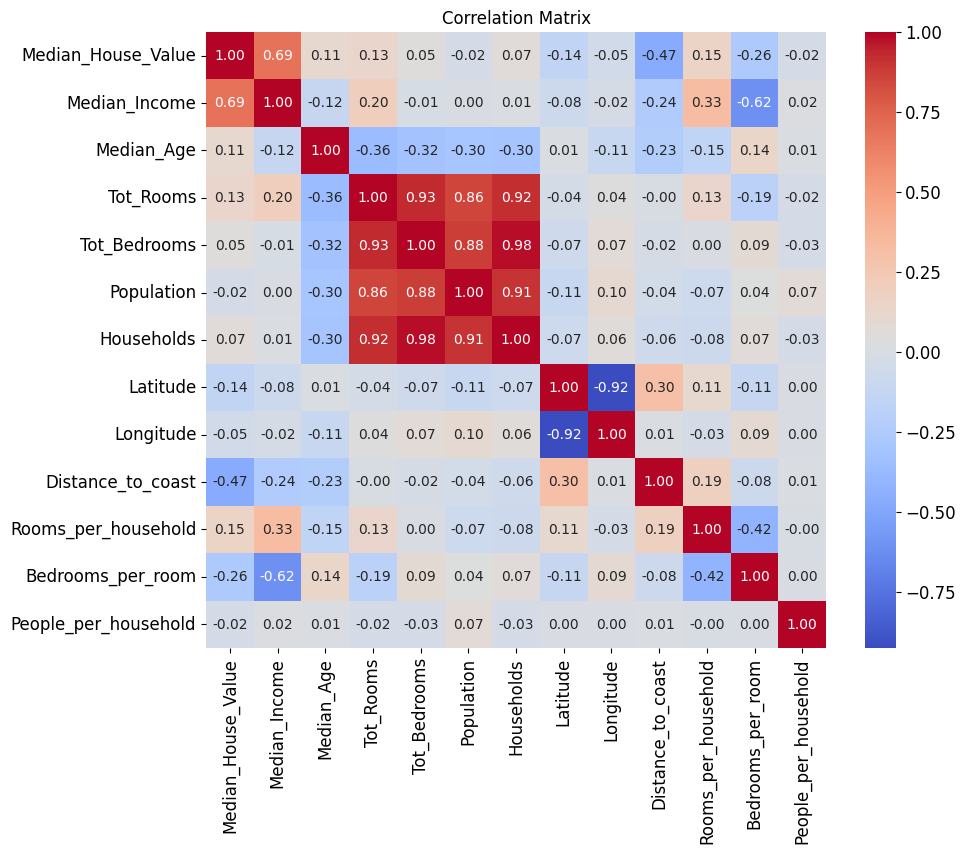

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Part 2 - Preparing data for Machine Learning

## 2.1 - Missing Values

### 2.1.1 - Case when there are missing values in one variable

Let us create a dataset where there are 10% of missing values in one variable

In [ ]:
## Randomly select 10% of the dataset indices to simulate missing values
## random.seed(42) ensures reproducibility of the random selection
## 1651 ≈ 10% of the training set size

import random
random.seed(42)
miss = np.random.choice(houses_df.index, 1651)

In [ ]:
miss

array([ 2427, 11681,  2994, ..., 14458, 19716, 10062])

In [ ]:
## Create a copy of the original training set to avoid modifying it directly.
## Working on a copy preserves houses_df intact for future use.

houses_miss = houses_df.copy()

In [ ]:
## Replace the values of Tot_Bedrooms with None (missing values) for the 1651 randomly selected indices stored in "miss".
## This artificially simulates a real-world scenario where ~10% of data is missing.

houses_miss.loc[miss,"Tot_Bedrooms"] = None

In [ ]:
#To get the info oh the modified copy training test
houses_miss.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 1405 to 4028
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Median_House_Value  16512 non-null  float64 
 1   Median_Income       16512 non-null  float64 
 2   Median_Age          16512 non-null  int64   
 3   Tot_Rooms           16512 non-null  int64   
 4   Tot_Bedrooms        14957 non-null  float64 
 5   Population          16512 non-null  int64   
 6   Households          16512 non-null  int64   
 7   Latitude            16512 non-null  float64 
 8   Longitude           16512 non-null  float64 
 9   Distance_to_coast   16512 non-null  float64 
 10  Closest_city        16512 non-null  category
 11  income_cat          16512 non-null  category
dtypes: category(2), float64(6), int64(4)
memory usage: 1.9 MB


In [ ]:
#We drop the rows associated to the missing values
houses_drop = houses_miss.dropna(subset=["Tot_Bedrooms"])

In [ ]:
#We check
houses_drop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14957 entries, 1405 to 4028
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Median_House_Value  14957 non-null  float64 
 1   Median_Income       14957 non-null  float64 
 2   Median_Age          14957 non-null  int64   
 3   Tot_Rooms           14957 non-null  int64   
 4   Tot_Bedrooms        14957 non-null  float64 
 5   Population          14957 non-null  int64   
 6   Households          14957 non-null  int64   
 7   Latitude            14957 non-null  float64 
 8   Longitude           14957 non-null  float64 
 9   Distance_to_coast   14957 non-null  float64 
 10  Closest_city        14957 non-null  category
 11  income_cat          14957 non-null  category
dtypes: category(2), float64(6), int64(4)
memory usage: 1.3 MB


In [ ]:
## Your comment here ##
#We imput the missing values by the median method
Bed_med = houses_miss["Tot_Bedrooms"].median()
houses_miss["Tot_Bedrooms"].fillna(Bed_med, inplace=True)

In [ ]:
#We check that we did it well

houses_miss.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 1405 to 4028
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Median_House_Value  16512 non-null  float64 
 1   Median_Income       16512 non-null  float64 
 2   Median_Age          16512 non-null  int64   
 3   Tot_Rooms           16512 non-null  int64   
 4   Tot_Bedrooms        16512 non-null  float64 
 5   Population          16512 non-null  int64   
 6   Households          16512 non-null  int64   
 7   Latitude            16512 non-null  float64 
 8   Longitude           16512 non-null  float64 
 9   Distance_to_coast   16512 non-null  float64 
 10  Closest_city        16512 non-null  category
 11  income_cat          16512 non-null  category
dtypes: category(2), float64(6), int64(4)
memory usage: 1.9 MB


### 2.1.2 - Case where you have missing values in several variables

Let us now build a dataset with multiple missing values : <br>
Start with a function generating missing values in a chosen column of a dataframe

In [ ]:
def col_miss (df, col, max_miss):
  df = df.copy()
  n_miss = np.random.randint(0, max_miss + 1)
  indices = np.random.choice(df.index, n_miss, replace=False)
  df.loc[indices, col] = np.nan
  return df



In [ ]:
# Copy the train set
housing_miss = houses_df.copy()
housing_miss.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 1405 to 4028
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Median_House_Value  16512 non-null  float64 
 1   Median_Income       16512 non-null  float64 
 2   Median_Age          16512 non-null  int64   
 3   Tot_Rooms           16512 non-null  int64   
 4   Tot_Bedrooms        16512 non-null  int64   
 5   Population          16512 non-null  int64   
 6   Households          16512 non-null  int64   
 7   Latitude            16512 non-null  float64 
 8   Longitude           16512 non-null  float64 
 9   Distance_to_coast   16512 non-null  float64 
 10  Closest_city        16512 non-null  category
 11  income_cat          16512 non-null  category
dtypes: category(2), float64(5), int64(5)
memory usage: 1.9 MB


Generate some missing values in the first 10 predictors of \<housing_miss>

In [ ]:
cols = housing_miss.columns[:10]

for col in cols:
    housing_miss = col_miss(housing_miss, col, 50)

housing_miss.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 1405 to 4028
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Median_House_Value    16378 non-null  float64 
 1   Median_Income         16318 non-null  float64 
 2   Median_Age            16416 non-null  float64 
 3   Tot_Rooms             16357 non-null  float64 
 4   Tot_Bedrooms          16370 non-null  float64 
 5   Population            16407 non-null  float64 
 6   Households            16309 non-null  float64 
 7   Latitude              16333 non-null  float64 
 8   Longitude             16266 non-null  float64 
 9   Distance_to_coast     16300 non-null  float64 
 10  Closest_city          16512 non-null  category
 11  income_cat            16512 non-null  category
 12  Rooms_per_household   16341 non-null  float64 
 13  Bedrooms_per_room     16382 non-null  float64 
 14  People_per_household  16348 non-null  float64 
dtypes: ca

Now, he have a dataset with missing values in all the quantitative predictors

#### How many missing values are there in each variable ?

In [ ]:
print(housing_miss.isna().sum())

Median_House_Value      134
Median_Income           194
Median_Age               96
Tot_Rooms               155
Tot_Bedrooms            142
Population              105
Households              203
Latitude                179
Longitude               246
Distance_to_coast       212
Closest_city              0
income_cat                0
Rooms_per_household     171
Bedrooms_per_room       130
People_per_household    164
dtype: int64


#### Let us use sklearn to do multiple imputation, with existing modules

In [ ]:
# Start with simple imputer
from sklearn.impute import SimpleImputer

**Using Simple Imputer, impute missing data in each variable by replacing missing values with the mean**

In [ ]:
## Using Simple Imputer ##
imputer = SimpleImputer(strategy='mean')

## Imputing missing data in ech variable ##
housing_num = housing_miss.select_dtypes(include=['float64', 'int64'])
X = housing_num.copy()

housing_imputed = pd.DataFrame(
    imputer.fit_transform(housing_num),
    columns=housing_num.columns
)


# Create SimpleImputer
imputer = SimpleImputer(strategy='mean')

# Fit and transform
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(housing_imputed.isna().sum())

Median_House_Value      0
Median_Income           0
Median_Age              0
Tot_Rooms               0
Tot_Bedrooms            0
Population              0
Households              0
Latitude                0
Longitude               0
Distance_to_coast       0
Rooms_per_household     0
Bedrooms_per_room       0
People_per_household    0
dtype: int64


In [ ]:
# Create SimpleImputer
imputer = SimpleImputer(strategy='mean')

# Fit and transform
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print(housing_imputed.isna().sum())




Median_House_Value      0
Median_Income           0
Median_Age              0
Tot_Rooms               0
Tot_Bedrooms            0
Population              0
Households              0
Latitude                0
Longitude               0
Distance_to_coast       0
Rooms_per_household     0
Bedrooms_per_room       0
People_per_household    0
dtype: int64


In [ ]:
X_df = pd.DataFrame(X, columns=df.columns)
X_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 1405 to 4028
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Median_House_Value    16378 non-null  float64
 1   Median_Income         16318 non-null  float64
 2   Median_Age            16416 non-null  float64
 3   Tot_Rooms             16357 non-null  float64
 4   Tot_Bedrooms          16370 non-null  float64
 5   Population            16407 non-null  float64
 6   Households            16309 non-null  float64
 7   Latitude              16333 non-null  float64
 8   Longitude             16266 non-null  float64
 9   Distance_to_coast     16300 non-null  float64
 10  Closest_city          0 non-null      float64
 11  income_cat            0 non-null      float64
 12  Rooms_per_household   16341 non-null  float64
 13  Bedrooms_per_room     16382 non-null  float64
 14  People_per_household  16348 non-null  float64
dtypes: float64(15)
memory 

**Using KNNImputer, impute missing data in each variable**

In [ ]:
X_numeric = X_df.copy()  # all numeric predictors

In [ ]:
X_numeric = X_df.select_dtypes(include=['float64', 'int64'])

In [ ]:
from sklearn.impute import KNNImputer
import pandas as pd

X_numeric = X_numeric.dropna(axis=1, how='all')

imputer = KNNImputer(n_neighbors=5)
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_numeric),
    columns=X_numeric.columns
)

print(X_imputed.isna().sum())

Median_House_Value      0
Median_Income           0
Median_Age              0
Tot_Rooms               0
Tot_Bedrooms            0
Population              0
Households              0
Latitude                0
Longitude               0
Distance_to_coast       0
Rooms_per_household     0
Bedrooms_per_room       0
People_per_household    0
dtype: int64


## 2.2 - Categorical variables...

In [ ]:
houses_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 1405 to 4028
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Median_House_Value  16512 non-null  float64 
 1   Median_Income       16512 non-null  float64 
 2   Median_Age          16512 non-null  int64   
 3   Tot_Rooms           16512 non-null  int64   
 4   Tot_Bedrooms        16512 non-null  int64   
 5   Population          16512 non-null  int64   
 6   Households          16512 non-null  int64   
 7   Latitude            16512 non-null  float64 
 8   Longitude           16512 non-null  float64 
 9   Distance_to_coast   16512 non-null  float64 
 10  Closest_city        16512 non-null  category
 11  income_cat          16512 non-null  category
dtypes: category(2), float64(5), int64(5)
memory usage: 1.9 MB


### 2.2.1 - Introducing onehot encoding

"Closest_city" has four modalities : the four city names <br>
"income_cat" has five modalities : the five intervals that we have labeled 1,2,3,4,5. However as you see in the graph and in the original values - cat =  [0.4999, 2.3523, 3.1406, 3.9669399999999997, 5.10972, 15.0001] these intervals are not equidistant, so you cannot really add nor substract them meaningfully. <br>
**In short, both categorical variables should be considered nominal**

In [ ]:
# Let us select our categorical variables
houses_cat = houses_df[["Closest_city","income_cat"]]

In [ ]:
# Call for onehot encoder. Choose a dense rather than a sparse vector
from sklearn.preprocessing import OneHotEncoder
onehot = OneHotEncoder(sparse_output=False)
houses_onehot = onehot.fit_transform(houses_cat)

In [ ]:
houses_onehot

array([[0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 1.]])

In [ ]:
onehot.categories_

[array(['Los Angeles', 'San Diego', 'San Francisco', 'San Jose'],
       dtype=object),
 array([1, 2, 3, 4, 5])]

### 2.2.2 - Building a Pipeline

Let us first discover how a pipeline operates...

In [ ]:
# Copying once again the original train set
housing_df = train_strat.copy()
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 1405 to 4028
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Median_House_Value  16512 non-null  float64 
 1   Median_Income       16512 non-null  float64 
 2   Median_Age          16512 non-null  int64   
 3   Tot_Rooms           16512 non-null  int64   
 4   Tot_Bedrooms        16512 non-null  int64   
 5   Population          16512 non-null  int64   
 6   Households          16512 non-null  int64   
 7   Latitude            16512 non-null  float64 
 8   Longitude           16512 non-null  float64 
 9   Distance_to_coast   16512 non-null  float64 
 10  Closest_city        16512 non-null  category
 11  income_cat          16512 non-null  category
dtypes: category(2), float64(5), int64(5)
memory usage: 1.9 MB


Let us start with a custom transformer to be used to add attributes

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

# column index
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self  # nothing else to do
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household,
                         bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]


In [ ]:
attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
houses_plus = attr_adder.transform(housing_df.values)

In [ ]:
# Checking the answer...

houses_plus_df = pd.DataFrame(houses_plus,
                              columns=list(housing_df.columns)+["rooms_per_household", "population_per_household"],
                              index=housing_df.index)

houses_plus_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 1405 to 4028
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Median_House_Value        16512 non-null  object
 1   Median_Income             16512 non-null  object
 2   Median_Age                16512 non-null  object
 3   Tot_Rooms                 16512 non-null  object
 4   Tot_Bedrooms              16512 non-null  object
 5   Population                16512 non-null  object
 6   Households                16512 non-null  object
 7   Latitude                  16512 non-null  object
 8   Longitude                 16512 non-null  object
 9   Distance_to_coast         16512 non-null  object
 10  Closest_city              16512 non-null  object
 11  income_cat                16512 non-null  object
 12  rooms_per_household       16512 non-null  object
 13  population_per_household  16512 non-null  object
dtypes: object(14)
memory usag

### 2.2.3 - Pipeline for the quantitative variables

For the quantitative variables, let us generate a pipeline with the following steps
1. Imputing missing values with the "median" method
2. Adding two new attributes : rooms per household and population per household
3. Standardizing the training set

#### Let us restart with a new training set from a dataset with missing values

In [ ]:
train = housing_miss[housing_miss.columns[0:12]]
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 1405 to 4028
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Median_House_Value  16463 non-null  float64 
 1   Median_Income       16491 non-null  float64 
 2   Median_Age          16476 non-null  float64 
 3   Tot_Rooms           16511 non-null  float64 
 4   Tot_Bedrooms        16478 non-null  float64 
 5   Population          16475 non-null  float64 
 6   Households          16506 non-null  float64 
 7   Latitude            16463 non-null  float64 
 8   Longitude           16464 non-null  float64 
 9   Distance_to_coast   16485 non-null  float64 
 10  Closest_city        16512 non-null  category
 11  income_cat          16512 non-null  category
dtypes: category(2), float64(10)
memory usage: 1.9 MB


In [ ]:
quanti_features = list(train.columns[:10])
cat_features = ["Closest_city","income_cat"]
train_quanti = train[quanti_features]

In [ ]:
train_quanti.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 1405 to 4028
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Median_House_Value  16463 non-null  float64
 1   Median_Income       16491 non-null  float64
 2   Median_Age          16476 non-null  float64
 3   Tot_Rooms           16511 non-null  float64
 4   Tot_Bedrooms        16478 non-null  float64
 5   Population          16475 non-null  float64
 6   Households          16506 non-null  float64
 7   Latitude            16463 non-null  float64
 8   Longitude           16464 non-null  float64
 9   Distance_to_coast   16485 non-null  float64
dtypes: float64(10)
memory usage: 1.9 MB


In [ ]:
imputer = SimpleImputer(strategy="median")
train_imputed = imputer.fit_transform(train_quanti)


In [ ]:
train_imputed_df = pd.DataFrame(
    train_imputed,
    columns=train_quanti.columns,
    index=train_quanti.index
)
train_imputed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 1405 to 4028
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Median_House_Value  16512 non-null  float64
 1   Median_Income       16512 non-null  float64
 2   Median_Age          16512 non-null  float64
 3   Tot_Rooms           16512 non-null  float64
 4   Tot_Bedrooms        16512 non-null  float64
 5   Population          16512 non-null  float64
 6   Households          16512 non-null  float64
 7   Latitude            16512 non-null  float64
 8   Longitude           16512 non-null  float64
 9   Distance_to_coast   16512 non-null  float64
dtypes: float64(10)
memory usage: 1.9 MB


**Defining the pipeline which will go through three steps :**
1. Imputing missing data with the median method
2. Combining three new attributes
3. Standardizing the quantitative features

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

quanti_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('attribs_adder', CombinedAttributesAdder()), # this will add 3 attributes
        ('std_scaler', StandardScaler()),
    ])

houses_quanti = quanti_pipeline.fit_transform(train_imputed_df)

In [ ]:
houses_quanti

array([[-0.21487102,  0.06244435, -1.4862891 , ..., -0.26868871,
        -0.09872139,  0.41312418],
       [ 1.28971889,  1.80957912, -1.64551112, ...,  0.50759136,
         0.07366044, -1.01938421],
       [-1.03358325, -0.09271604,  0.02632004, ...,  0.01327034,
        -0.04374919, -0.54759303],
       ...,
       [-1.23066457, -0.5917684 , -0.05329097, ..., -0.03733341,
         0.05224864, -0.30863977],
       [ 0.74796234,  1.81340368, -1.00862306, ..., -0.03366721,
        -0.08628402, -0.71419572],
       [ 2.17528249,  0.82055774,  0.82243011, ...,  0.42039849,
        -0.02858459, -0.90816454]])

### 2.2.4 - Pipeline for the quantitative and categorical variables

Now let us include the categorical variables

In [ ]:
#checking categorical variables at the origin
cat_features = train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Colonnes catégorielles trouvées : {cat_features}")

Colonnes catégorielles trouvées : ['Closest_city', 'income_cat']


In [ ]:
#adding categorical variables to the train_imputed_df
train_imputed_df['Closest_city'] = train['Closest_city']
train_imputed_df['income_cat'] = train['income_cat']
train_imputed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 1405 to 4028
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Median_House_Value  16512 non-null  float64 
 1   Median_Income       16512 non-null  float64 
 2   Median_Age          16512 non-null  float64 
 3   Tot_Rooms           16512 non-null  float64 
 4   Tot_Bedrooms        16512 non-null  float64 
 5   Population          16512 non-null  float64 
 6   Households          16512 non-null  float64 
 7   Latitude            16512 non-null  float64 
 8   Longitude           16512 non-null  float64 
 9   Distance_to_coast   16512 non-null  float64 
 10  Closest_city        16512 non-null  category
 11  income_cat          16512 non-null  category
dtypes: category(2), float64(10)
memory usage: 1.9 MB


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder as OHE
quanti_features = [col for col in train_imputed_df.columns
                   if col not in ["Median_House_Value", "Closest_city", "income_cat"]]
full_pipeline = ColumnTransformer([
        ("num", quanti_pipeline, quanti_features),
        ("cat", OHE(), cat_features),
    ])

houses_ready = full_pipeline.fit_transform(train_imputed_df)

# Part 3 - Machine Learning

First of all, define the target (outcome) and the predictors (features)

In [ ]:
y = train_imputed_df["Median_House_Value"]
X = full_pipeline.fit_transform(train_imputed_df)


## 3.1 - Learning and evaluating with the training set only

#### Linear Regression
Starting with the most classical Linear Regression <br>
Checking that this algorithm does not use Ordinary Least Square with matrix inversion

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X, y)
print("Solver used (not OLS matrix inversion) : SVD via scipy.linalg.lstsq")

Solver used (not OLS matrix inversion) : SVD via scipy.linalg.lstsq


Estimating performance with Mean Squared Error and Mean Absolute Error

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
y_pred_lr = lr.predict(X)

In [ ]:
mse = mean_squared_error(y, y_pred_lr)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred_lr)

print(f"MSE  : {mse:,.0f}")
print(f"RMSE : {rmse:,.0f}")
print(f"MAE  : {mae:,.0f}")

MSE  : 4,736,689,510
RMSE : 68,824
MAE  : 50,160


#### Decision Tree Regression

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X, y)

y_pred_tree = tree.predict(X)

mse_tree  = mean_squared_error(y, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
mae_tree  = mean_absolute_error(y, y_pred_tree)

print(f"MSE  : {mse_tree:,.0f}")
print(f"RMSE : {rmse_tree:,.0f}")
print(f"MAE  : {mae_tree:,.0f}")

MSE  : 0
RMSE : 0
MAE  : 0


Estimating performance with Mean Squared Error and Mean Absolute Error

In [ ]:
mse_tree  = mean_squared_error(y, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
mae_tree  = mean_absolute_error(y, y_pred_tree)

print(f"MSE  : {mse_tree:,.0f}")
print(f"RMSE : {rmse_tree:,.0f}")
print(f"MAE  : {mae_tree:,.0f}")

MSE  : 0
RMSE : 0
MAE  : 0


## 3.2 - Estimating the models with *cross validation*

In [ ]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

#### Linear Regression

In [ ]:
lr = LinearRegression()

In [ ]:
from sklearn.model_selection import cross_val_score

lr_scores = cross_val_score(lr, X, y, scoring="neg_mean_squared_error", cv=10)
lr_rmse = np.sqrt(-lr_scores)
display_scores(lr_rmse)

Scores: [72195.72204214 67061.98243571 71968.80969857 71887.86597348
 70694.17273468 69260.05466819 70243.94083232 67161.85847024
 65035.11640582 65435.78679766]
Mean: 69094.53100588097
Standard deviation: 2594.6235117426313


#### Penalized Linear Regression (Elasticnet)

In [ ]:
from sklearn.linear_model import ElasticNet

In [ ]:
elasticnet = ElasticNet(random_state=42)
elasticnet.fit(X, y)

en_scores = cross_val_score(elasticnet, X, y, scoring="neg_mean_squared_error", cv=10)
en_rmse = np.sqrt(-en_scores)
display_scores(en_rmse)

Scores: [78490.21346107 73532.45582936 78587.19966615 78276.63656808
 74569.40774487 78837.80007509 78558.93392182 74837.68034409
 72689.62125331 72105.75687818]
Mean: 76048.57057420167
Standard deviation: 2612.7685065544556


#### Decision Trees

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)

tree_scores = cross_val_score(tree, X, y, scoring="neg_mean_squared_error", cv=10)
tree_rmse = np.sqrt(-tree_scores)
display_scores(tree_rmse)

Scores: [72631.10040004 72271.26524967 68238.69734206 71203.43938278
 69675.6943912  71232.97027584 70210.97633033 69871.10694342
 68155.32987218 67479.85109091]
Mean: 70097.04312784357
Standard deviation: 1672.6651646150935


#### Random Forests

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf_scores = cross_val_score(rf, X, y, scoring="neg_mean_squared_error", cv=10)
rf_rmse = np.sqrt(-rf_scores)
display_scores(rf_rmse)

Scores: [55114.03945212 48535.72838919 52377.31322639 51203.73241081
 47790.17529308 48612.26456197 50159.00503309 49484.94745471
 47979.44377147 47171.81655941]
Mean: 49842.846615224305
Standard deviation: 2330.9241632955896


#### Support Vector Machines

In [ ]:
from sklearn.svm import SVR

svm = SVR()

svm_scores = cross_val_score(svm, X, y, scoring="neg_mean_squared_error", cv=5)
svm_rmse = np.sqrt(-svm_scores)
display_scores(svm_rmse)

Scores: [115535.07287034 121044.1475004  119053.99546021 119389.1679344
 114861.41497396]
Mean: 117976.75974786263
Standard deviation: 2376.1906134783785


## 3.3 - Tuning the model with Grid Search and Randomized Search

#### Example : Random Forest

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
rf_grid = {'n_estimators': [30,60,100], 'max_features': [8,10,15]}

from sklearn.model_selection import GridSearchCV

rf_grid = {'n_estimators': [30,60,100], 'max_features': [8,10,15]}

grid_search_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)
grid_search_rf.fit(X, y)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_features': [8, 10, 15],
                         'n_estimators': [30, 60, 100]},
             scoring='neg_mean_squared_error')

In [ ]:
## Display the hyperparameters of the best model (code) ##
print("Meilleurs hyperparamètres :", grid_search_rf.best_params_)

Meilleurs hyperparamètres : {'max_features': 10, 'n_estimators': 100}


In [ ]:
## Print the score of the best model (code)##
best_rmse_rf = np.sqrt(-grid_search_rf.best_score_)
print(f"Meilleur RMSE (CV) : {best_rmse_rf:,.0f}")

Meilleur RMSE (CV) : 49,994


#### Example : ElasticNet

In [ ]:
en_grid = {'alpha': np.logspace(-3, 4, 10), 'l1_ratio':np.linspace(0,1,11) }

grid_search_en = GridSearchCV(
    ElasticNet(random_state=42),
    en_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)
grid_search_en.fit(X, y)

GridSearchCV(cv=5, estimator=ElasticNet(random_state=42), n_jobs=-1,
             param_grid={'alpha': array([1.00000000e-03, 5.99484250e-03, 3.59381366e-02, 2.15443469e-01,
       1.29154967e+00, 7.74263683e+00, 4.64158883e+01, 2.78255940e+02,
       1.66810054e+03, 1.00000000e+04]),
                         'l1_ratio': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])},
             scoring='neg_mean_squared_error')

In [ ]:
## Display the hyperparameters of the best model (code) ##
print("Meilleurs hyperparamètres :", grid_search_en.best_params_)

Meilleurs hyperparamètres : {'alpha': np.float64(46.41588833612782), 'l1_ratio': np.float64(1.0)}


In [ ]:
## Print the score of the best model (code)##
best_rmse_en = np.sqrt(-grid_search_en.best_score_)
print(f"Meilleur RMSE (CV) : {best_rmse_en:,.0f}")

Meilleur RMSE (CV) : 69,162


#### Example Decision Tree

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
cart_grid = {"min_samples_split": range(1,10),"min_samples_leaf": range(1,60)}

random_search_tree = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    cart_grid,
    n_iter=20,
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)
random_search_tree.fit(X, y)


RandomizedSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'min_samples_leaf': range(1, 60),
                                        'min_samples_split': range(1, 10)},
                   random_state=42, scoring='neg_mean_squared_error')

In [ ]:
## Display the hyperparameters of the best model (code) ##
print("Meilleurs hyperparamètres :", random_search_tree.best_params_)

Meilleurs hyperparamètres : {'min_samples_split': 6, 'min_samples_leaf': 21}


In [ ]:
## Print the score of the best model (code)##
best_rmse_tree = np.sqrt(-random_search_tree.best_score_)
print(f"Meilleur RMSE (CV) : {best_rmse_tree:,.0f}")

Meilleur RMSE (CV) : 58,329


## 3.4 - Final question : how good are our models in predicting unseen data ?

In [ ]:
# Start by checking the structure of the test set (code) #
## Your code here ##
print(test_strat.info())
print(test_strat.describe())
print(test_strat.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 4128 entries, 15498 to 183
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Median_House_Value  4128 non-null   float64 
 1   Median_Income       4128 non-null   float64 
 2   Median_Age          4128 non-null   int64   
 3   Tot_Rooms           4128 non-null   int64   
 4   Tot_Bedrooms        4128 non-null   int64   
 5   Population          4128 non-null   int64   
 6   Households          4128 non-null   int64   
 7   Latitude            4128 non-null   float64 
 8   Longitude           4128 non-null   float64 
 9   Distance_to_coast   4128 non-null   float64 
 10  Closest_city        4128 non-null   category
 11  income_cat          4128 non-null   category
dtypes: category(2), float64(5), int64(5)
memory usage: 363.2 KB
None
       Median_House_Value  Median_Income   Median_Age     Tot_Rooms  \
count         4128.000000    4128.000000  4128.000000 